In [1]:
import pandas as pd
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    export_text
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor)
from xgboost import XGBClassifier, XGBRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv("heart_disease.csv")

# Task 1: Load and Prepare the Data

In [3]:
X = df.drop(columns="target")
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Task 2: Train a Single Decision Tree

In [4]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt.predict(X_test))

print("Decision Tree train accuracy: ", round(dt_train_acc,3))
print("Decision Tree test accuracy:  ", round(dt_test_acc, 3))

Decision Tree train accuracy:  1.0
Decision Tree test accuracy:   0.685


-  Training accuracy is very good at predicting information it has seen before but has trouble when introduced to new data. 

-  The model is overfit

# Task 3: Visualize the Decision Tree

In [5]:
X.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

In [6]:
feature_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

print(export_text(
    dt,
    feature_names=feature_names

))

print(f" leaves = {dt.get_n_leaves()}")
print(f" depth = {dt.get_depth()}")

|--- cp <= 2.50
|   |--- oldpeak <= 2.45
|   |   |--- thal <= 1.50
|   |   |   |--- chol <= 272.00
|   |   |   |   |--- trestbps <= 109.00
|   |   |   |   |   |--- chol <= 232.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- chol >  232.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- trestbps >  109.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- chol >  272.00
|   |   |   |   |--- oldpeak <= 1.35
|   |   |   |   |   |--- thalach <= 138.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- thalach >  138.00
|   |   |   |   |   |   |--- chol <= 330.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- chol >  330.00
|   |   |   |   |   |   |   |--- chol <= 337.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- chol >  337.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- oldpeak >  1.35
|   |   |   |   |   |--- class: 1
|   |   |--- thal >  1.50
|   |   |   |--- thalac

-  depth: 10
-  leaf node count: 36
-  first question: "cp <= 2.50

# Task 4: Train a Random Forest

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf.predict(X_test))

print(f"RF Training Accuracy: {rf_train_acc}")
print(f"RF Test Accuracy: {rf_test_acc}")

print("Decision Tree train accuracy: ", round(dt_train_acc,3))
print("Decision Tree test accuracy:  ", round(dt_test_acc, 3))

RF Training Accuracy: 1.0
RF Test Accuracy: 0.7962962962962963
Decision Tree train accuracy:  1.0
Decision Tree test accuracy:   0.685


-  Test accuracy improved on the Random Forest Model by ~10%
-  The gap did get smaller, this suggests that overfitting wasn't as prominent as it was in the Decision Tree model.

# Task 5: Train an XGBoost Model

- XGBoost outperformed the random forest, in both it's test accuracy and gap. We assume this may be due to the settings our XGBoost has, as tweaking learning_rate will fluctuate the test accuracy.

In [16]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=.1,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
xgb_train_acc = accuracy_score(y_train, xgb.predict(X_train))
xgb_test_acc = accuracy_score(y_test, xgb.predict(X_test))
print("XGBoost train accuracy: ", round(xgb_train_acc,3))
print("XGBoost test accuracy:  ", round(xgb_test_acc, 3))


XGBoost train accuracy:  1.0
XGBoost test accuracy:   0.852


# Task 6: Compare All Three Models

- We would recommend the XGBoost model to the hospital team, as it will perform the most consistently with new data. Additionally, if eventually the data-set gets modified, XGBoost has a high chance of being able to be tweaked in such a way that it will continue to perform well.

| Model           | Train Accuracy | Test Accuracy |
|-----------------|----------------|---------------|
| Decision Tree   |1.0             |.69            |
| Random Forest   |1.0             |.79            |
| XGBoost         |1.0             |.85            |

### Task 7: Plot Feature Importances

- 'oldpeak' had the greatest importance on the model's predictions. We are assuming 'oldpeak' means the peak heart-rate, which we would expect to suggest a higher likelihood of heart disease.

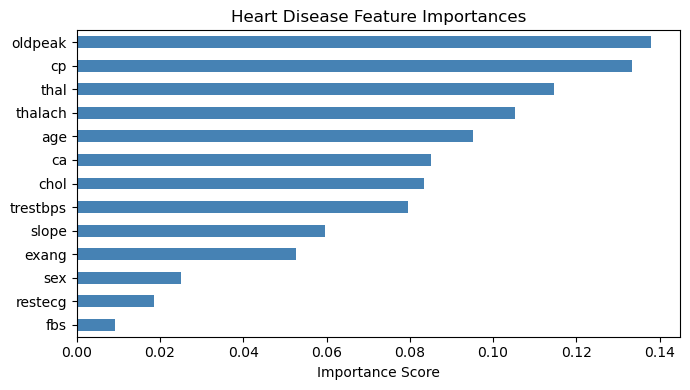

In [18]:
importances = pd.Series(rf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance Score")
ax.set_title("Heart Disease Feature Importances")
plt.tight_layout()
plt.show()

### Advanced Task 1: Use Cross-Validation to Compare Models

- The rankings did change, with Random Forest now outperforming XGBoost, although they both have the same standard deviation. A lower standard deviation in this context means the models performed more consistently across multiple folds, and as such is favorable.

In [20]:
models = {"Random Forest": rf, "Decision Tree:": dt, "XGBoost": xgb}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5,
                             scoring="accuracy")
    print(f"{name:<20} {scores.mean():>8.2f}  {scores.std():>7.2f}")

Random Forest            0.81     0.06
Decision Tree:           0.72     0.09
XGBoost                  0.79     0.06


### Advanced Task 2:

- Test Accuracy peaked at depth 5, at about .7. The relationship between training and test accuracy first tightened, then began to spread.

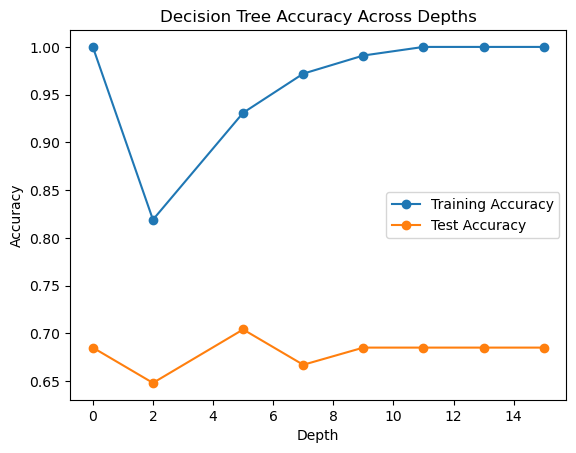

In [33]:
test_depths = [0, 2, 5, 7, 9, 11, 13, 15]
training_accuracies = []
test_accuracies = []
for x in test_depths:
    if x == 0:
        value = None
    else:
        value = x
    dt = DecisionTreeClassifier(max_depth=value, random_state=42)

    dt.fit(X_train, y_train)

    dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
    dt_test_acc = accuracy_score(y_test, dt.predict(X_test))
    training_accuracies.append(round(dt_train_acc, 3))
    test_accuracies.append(round(dt_test_acc, 3))
    #if x == None:
       # plt.plot(0, dt_train_acc, 'o', label=f'Depth {x} Training Accuracy')
        #plt.plot(0, dt_test_acc, 'o', label=f'Depth {x} Test Accuracy.')
   # else:
       # plt.plot(x, dt_train_acc, 'o', label=f'Depth {x} Training Accuracy')
       # plt.plot(x, dt_test_acc, 'o', label=f'Depth {x} Test Accuracy.')
    #print("Decision Tree train accuracy: ", round(dt_train_acc,3))
    #print("Decision Tree test accuracy:  ", round(dt_test_acc, 3))

plt.plot(test_depths, training_accuracies, marker='o', label='Training Accuracy')
plt.plot(test_depths, test_accuracies, marker='o', label='Test Accuracy')

plt.title('Decision Tree Accuracy Across Depths')
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### Extra Credit:

- While the two models largely agree on important features, there is some disagreement. Particular in CP, wherein XGBoost values it significantly higher than the random forest. Random Forest will shuffle features to attempt to combat one feature becoming dominant, which could explain why it didn't value CP as highly as our XGBoost model. Correlated features will affect the scores, as they positively reinforce their total relationship, despite potentially weighing down each individual feature importance.

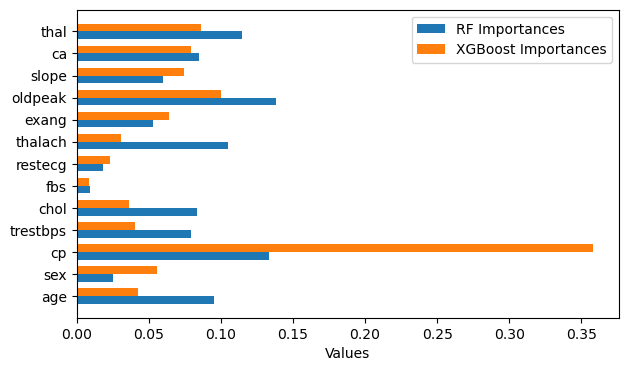

In [75]:
import numpy as np

importances = pd.Series(rf.feature_importances_, index=feature_names)
importances_xgb = pd.Series(xgb.feature_importances_, index=feature_names)

n_categories = len(feature_names)
y_pos = np.arange(n_categories)
bar_width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(y_pos - bar_width/2, importances, height=bar_width, label='RF Importances')
ax.barh(y_pos + bar_width/2, importances_xgb, height=bar_width, label='XGBoost Importances')


ax.set_yticks(y_pos)
ax.set_yticklabels(feature_names)
ax.set_xlabel('Values')
ax.legend()
plt.show()

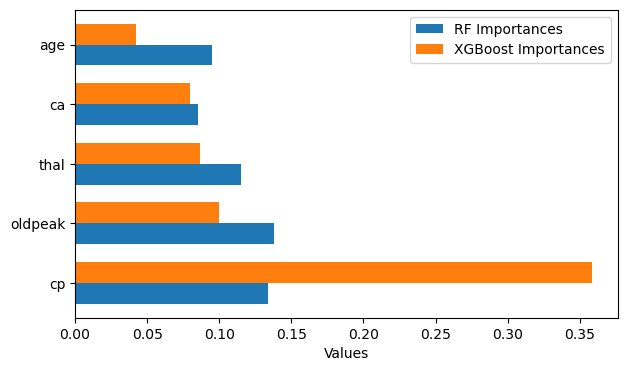

In [73]:
total_importance = importances_xgb + importances
total_importance = total_importance.sort_values(ascending=False).iloc[:5]

n_categories = len(total_importance)
y_pos = np.arange(n_categories)

importances_aligned = importances.reindex(total_importance.index).iloc[:5]
importances_xgb_aligned = importances_xgb.reindex(total_importance.index).iloc[:5]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(y_pos - bar_width/2, importances_aligned, height=bar_width, label='RF Importances')
ax.barh(y_pos + bar_width/2, importances_xgb_aligned, height=bar_width, label='XGBoost Importances')


ax.set_yticks(y_pos)
ax.set_yticklabels(total_importance.index)
ax.set_xlabel('Values')
ax.legend()
plt.show()